<a href="https://colab.research.google.com/github/Valtern/PCVK_Ganjil_2025/blob/main/week11_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import google.colab.drive
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# D1 Practicum

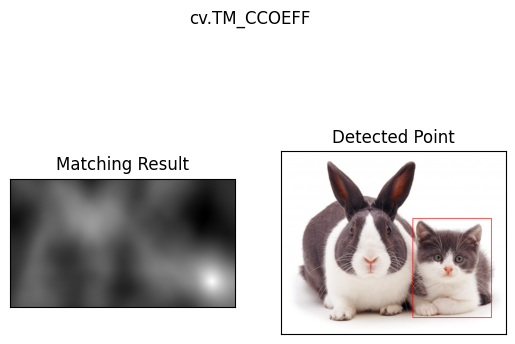

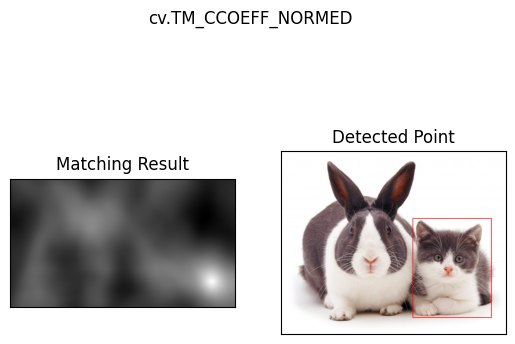

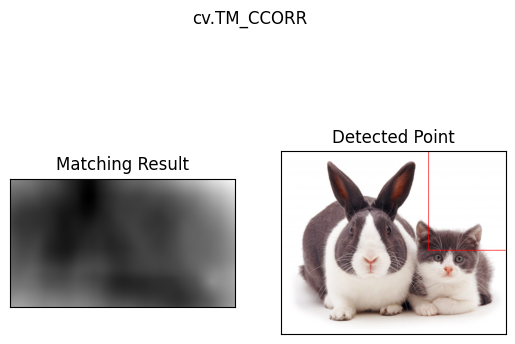

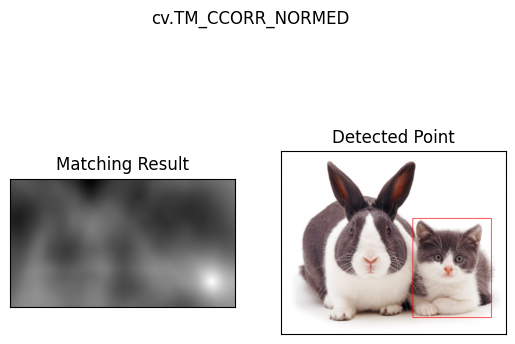

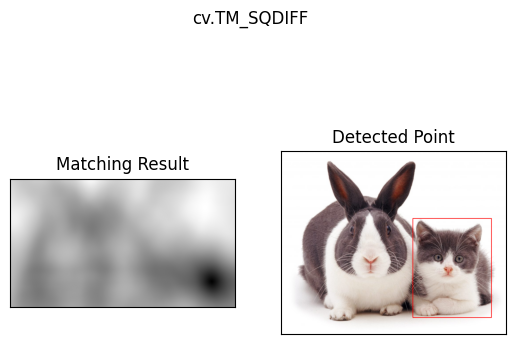

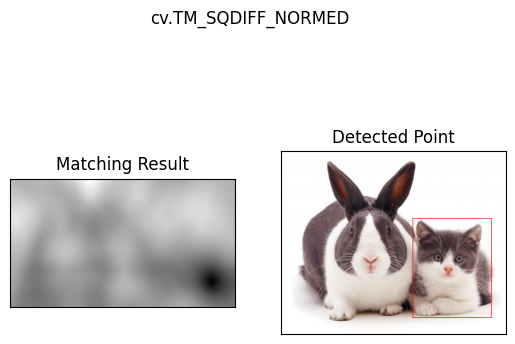

In [4]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/cats_and_bunnies.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/cat2_templatejpg.jpg', 0)
w, h = template.shape[::-1]

methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
           'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

for meth_name in methods:
    img_color_copy = img_color.copy()
    method = eval(meth_name)

    res = cv.matchTemplate(img_gray, template, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv.rectangle(img_color_copy, top_left, bottom_right, (0, 0, 255), 2)

    img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_rgb)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth_name)
    plt.show()

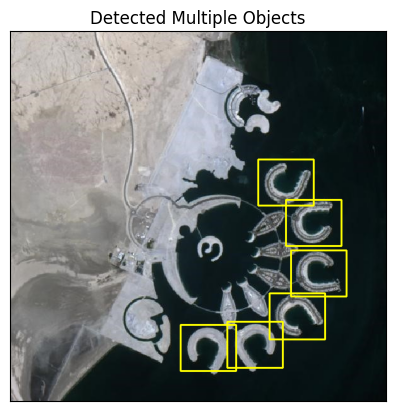

In [5]:
img_rgb = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain.jpg')
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain-template.jpg', 0)
w, h = template.shape[::-1]

res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

threshold = 0.45
loc = np.where(res >= threshold)

rectangles = []
for pt in zip(*loc[::-1]):
    rect = [int(pt[0]), int(pt[1]), int(w), int(h)]
    rectangles.append(rect)

boxes, weights = cv.groupRectangles(rectangles, 1, 0.2)

img_bgr_with_boxes = img_rgb.copy()
for (x, y, w, h) in boxes:
    cv.rectangle(img_bgr_with_boxes, (x, y), (x + w, y + h), (0, 255, 255), 2)

img_rgb_with_boxes = cv.cvtColor(img_bgr_with_boxes, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb_with_boxes)
plt.title('Detected Multiple Objects')
plt.xticks([]), plt.yticks([])
plt.show()

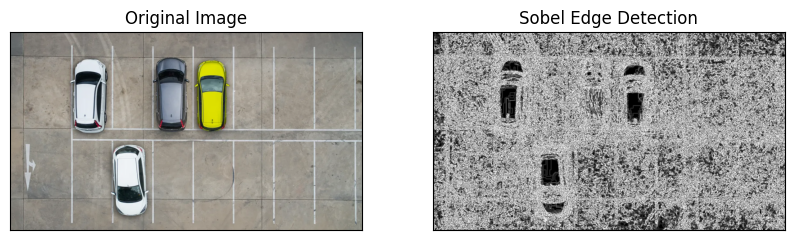

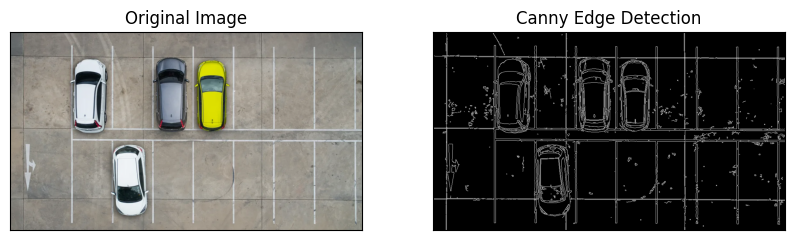

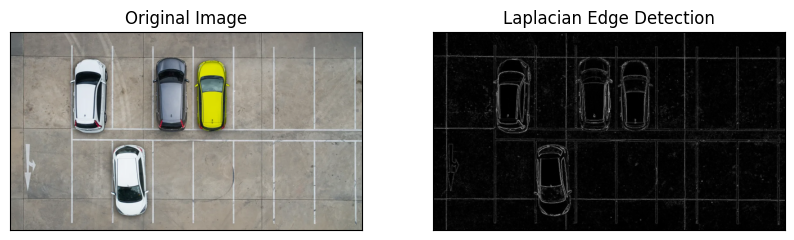

In [6]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/car-park.jpg')
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# Sobel Edge Detection

sobelx = cv.Sobel(img_gray, cv.CV_64F, 1, 0, ksize=5)
sobely = cv.Sobel(img_gray, cv.CV_64F, 0, 1, ksize=5)
sobel_combined = cv.bitwise_or(np.uint8(np.absolute(sobelx)),
                             np.uint8(np.absolute(sobely)))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

# Canny Edge Detection

canny_edges = cv.Canny(img_gray, 50, 150)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

# Laplacian Edge Detection

laplacian = cv.Laplacian(img_gray, cv.CV_64F)
laplacian_abs = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

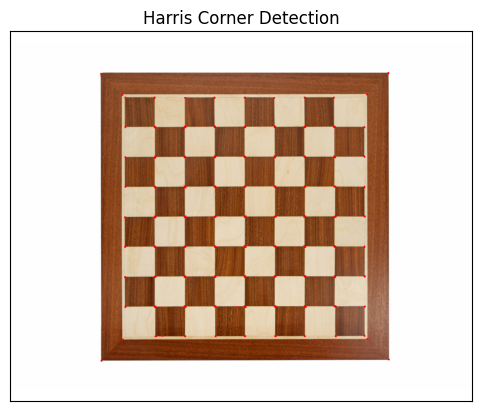

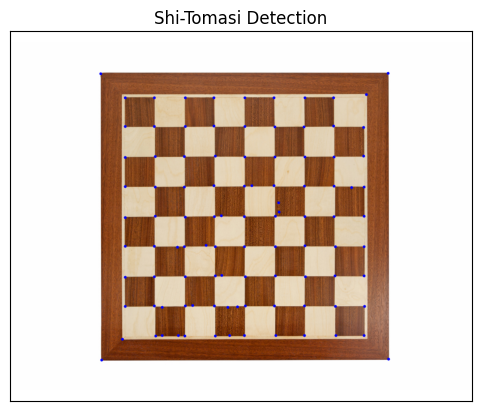

In [7]:
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/chess-board.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# a. Harris Corner Detection

img_harris = img_rgb.copy()

gray_float = np.float32(img_gray)
dst = cv.cornerHarris(gray_float, 2, 3, 0.04)

dst = cv.dilate(dst, None)

img_harris[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(img_harris)
plt.title('Harris Corner Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# Shi-Tomasi Detection

img_shi_tomasi = img_rgb.copy()

corners = cv.goodFeaturesToTrack(img_gray, 100, 0.01, 10)
corners = np.intp(corners)

for i in corners:
    x, y = i.ravel()
    cv.circle(img_shi_tomasi, (x, y), 3, (0, 0, 255), -1)

plt.imshow(img_shi_tomasi)
plt.title('Shi-Tomasi Detection')
plt.xticks([]), plt.yticks([])
plt.show()

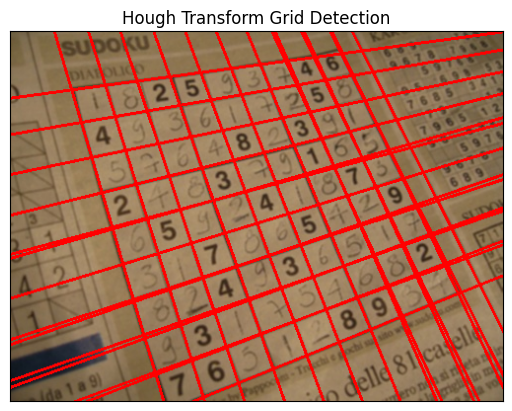

In [8]:
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/sudoku.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_color_copy = img.copy()

edges = cv.Canny(img_gray, 50, 150, apertureSize=3)

kernel = np.ones((3,3), np.uint8)
img_dilation = cv.dilate(edges, kernel, iterations=1)

img_erosion = cv.erode(img_dilation, kernel, iterations=1)

lines = cv.HoughLines(img_erosion, 1, np.pi / 175, 290)

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv.line(img_color_copy, (x1, y1), (x2, y2), (0, 0, 255), 2)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Hough Transform Grid Detection')
plt.xticks([]), plt.yticks([])
plt.show()

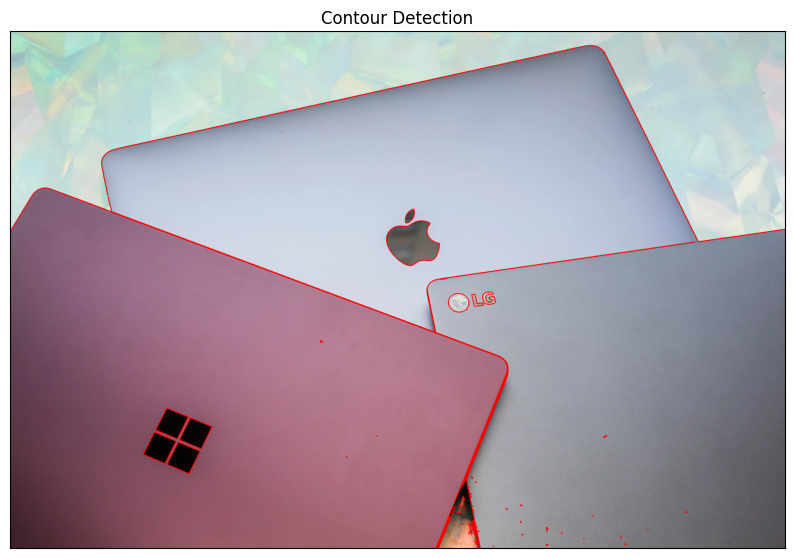

In [9]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/laptop.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

edges = cv.Canny(img_gray, 50, 150)

contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

img_color_copy = img_color.copy()

cv.drawContours(img_color_copy, contours, -1, (0, 0, 255), 3)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title('Contour Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# D2 Practicum

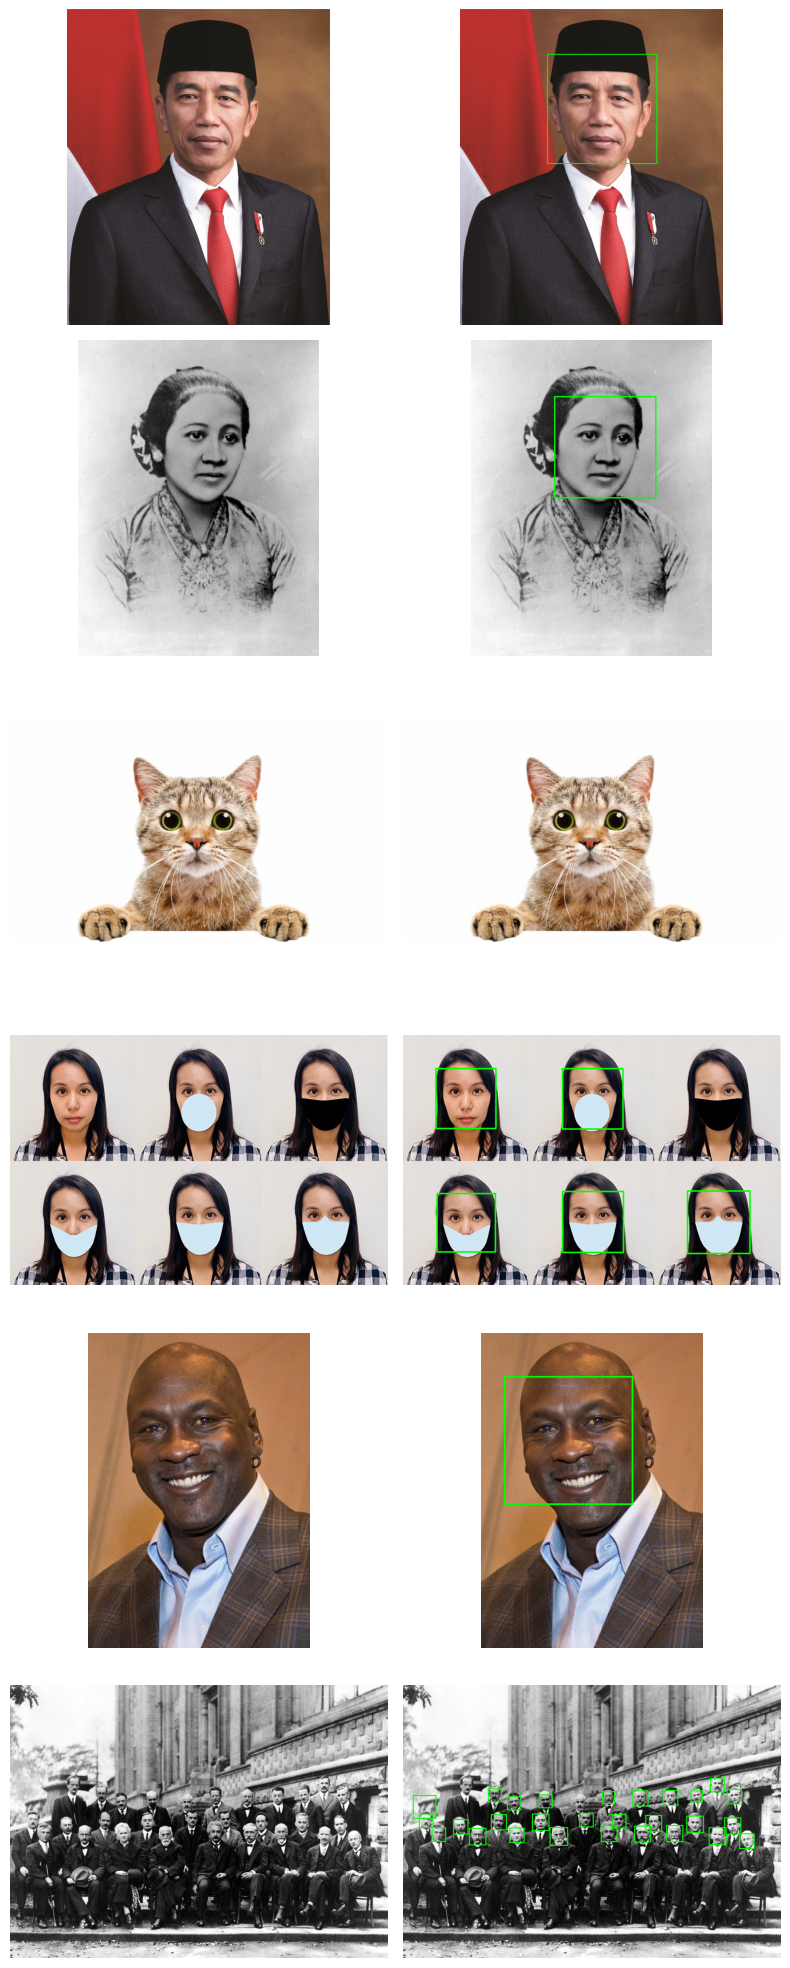

In [10]:
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalface_alt.xml')

image_filenames = [
    'jokowi.jpg',
    'kartini.jpg',
    'kucing.jpg',
    'mask.png',
    'mjordan.jpg',
    'solvayconf.jpg'
]

base_path = '/content/drive/MyDrive/PCVK/facedet/'

fig, axs = plt.subplots(len(image_filenames), 2, figsize=(8, 20))

for i, filename in enumerate(image_filenames):
    img_path = base_path + filename

    img_color = cv.imread(img_path)

    if img_color is None:
        print(f"Error: Could not read image at {img_path}. Skipping.")
        continue

    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

    img_original_display = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
    img_detected_display = img_original_display.copy()

    for (x, y, w, h) in faces:
        cv.rectangle(img_detected_display, (x, y), (x + w, y + h), (0, 255, 0), 2)

    axs[i, 0].imshow(img_original_display)
    axs[i, 0].axis('off')

    axs[i, 1].imshow(img_detected_display)
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

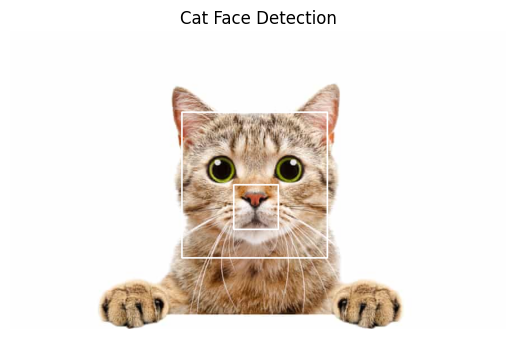

In [11]:
cat_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalcatface.xml'
cat_cascade = cv.CascadeClassifier(cat_cascade_path)

if cat_cascade.empty():
    print(f"Error: Could not load cascade classifier from {cat_cascade_path}")
else:
    img_path = '/content/drive/MyDrive/PCVK/facedet/kucing.jpg'
    img_color = cv.imread(img_path)

    if img_color is None:
        print(f"Error: Could not read image at {img_path}.")
    else:
        img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

        cat_faces = cat_cascade.detectMultiScale(img_gray, 1.1, 4)

        img_color_copy = img_color.copy()
        for (x, y, w, h) in cat_faces:
            cv.rectangle(img_color_copy, (x, y), (x + w, y + h), (255, 255, 255), 2)

        img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

        plt.imshow(img_rgb)
        plt.title('Cat Face Detection')
        plt.axis('off')
        plt.show()

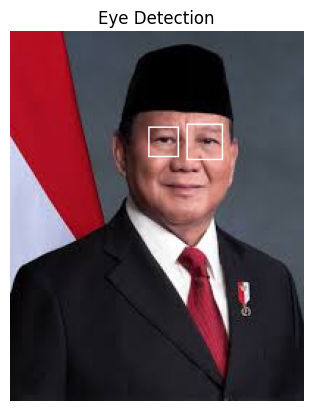

In [12]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalface_alt.xml'
eye_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_eye.xml'
face_cascade = cv.CascadeClassifier(face_cascade_path)
eye_cascade = cv.CascadeClassifier(eye_cascade_path)

img_path = '/content/drive/MyDrive/PCVK/Image/prabowo.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, 1.4, 4)

img_color_copy = img_color.copy()

for (x,y,w,h) in faces:
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_color_copy[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex,ey,ew,eh) in eyes:
        cv.rectangle(roi_color, (ex,ey), (ex+ew, ey+eh), (255, 255, 255), 1)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Eye Detection')
plt.axis('off')
plt.show()

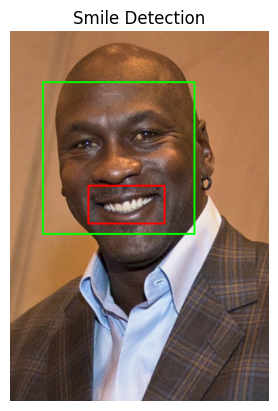

In [13]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalface_alt.xml'
smile_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_smile.xml'

face_cascade = cv.CascadeClassifier(face_cascade_path)
smile_cascade = cv.CascadeClassifier(smile_cascade_path)

img_path = '/content/drive/MyDrive/PCVK/facedet/mjordan.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, 1.3, 5)

img_color_copy = img_color.copy()

for (x, y, w, h) in faces:
    cv.rectangle(img_color_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)

    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_color_copy[y:y+h, x:x+w]

    smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20)

    for (sx, sy, sw, sh) in smiles:
        cv.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Smile Detection')
plt.axis('off')
plt.show()

In [14]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import PIL
import io
import html
import time

In [15]:
def js_to_image(js_reply):
  image_bytes = b64decode(js_reply.split(',')[1])
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  img = cv2.imdecode(jpg_as_np, flags=1)
  return img

def bbox_to_bytes(bbox_array):
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  bbox_PIL.save(iobuf, format='png')
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))
  return bbox_bytes

In [16]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalface_alt.xml'
face_cascade = cv2.CascadeClassifier(face_cascade_path)

In [17]:
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
      stream.getVideoTracks()[0].stop();
      video.remove();
      div.remove();
      video = null;
      div = null;
      stream = null;
      imgElement = null;
      captureCanvas = null;
      labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }
      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "user"}});
      div.appendChild(video);
      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();
      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640;
      captureCanvas.height = 480;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }
      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')
  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

In [18]:
video_stream()
label_html = 'Capturing...'
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    img = js_to_image(js_reply["img"])
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray)

    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    bbox_bytes = bbox_to_bytes(bbox_array)
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

/tmp/ipython-input-2517115048.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


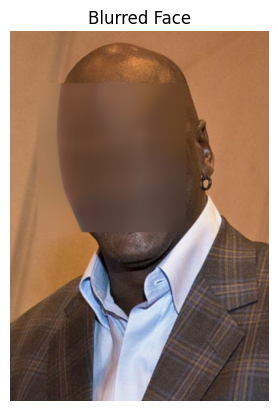

In [19]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalface_alt.xml'
face_cascade = cv.CascadeClassifier(face_cascade_path)

img_path = '/content/drive/MyDrive/PCVK/facedet/mjordan.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

img_color_copy = img_color.copy()

for (x, y, w, h) in faces:
    face_roi = img_color_copy[y:y+h, x:x+w]

    blurred_face = cv.medianBlur(face_roi, 99)

    img_color_copy[y:y+h, x:x+w] = blurred_face

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Blurred Face')
plt.axis('off')
plt.show()

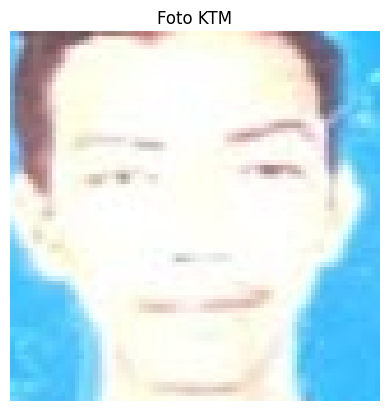

In [20]:
face_cascade_path = '/content/drive/MyDrive/PCVK/haarcascade/haarcascade_frontalface_alt.xml'
face_cascade = cv.CascadeClassifier(face_cascade_path)

img_path = '/content/drive/MyDrive/PCVK/Image/KTM lama.jpg'
img_color = cv.imread(img_path)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(img_gray, 1.1, 4)

if len(faces) > 0:
    (x, y, w, h) = faces[0]

    photo_roi = img_color[y:y+h, x:x+w]

    photo_rgb = cv.cvtColor(photo_roi, cv.COLOR_BGR2RGB)

    plt.imshow(photo_rgb)
    plt.title('Foto KTM')
    plt.axis('off')
    plt.show()
else:
    print("No face found in the image.")

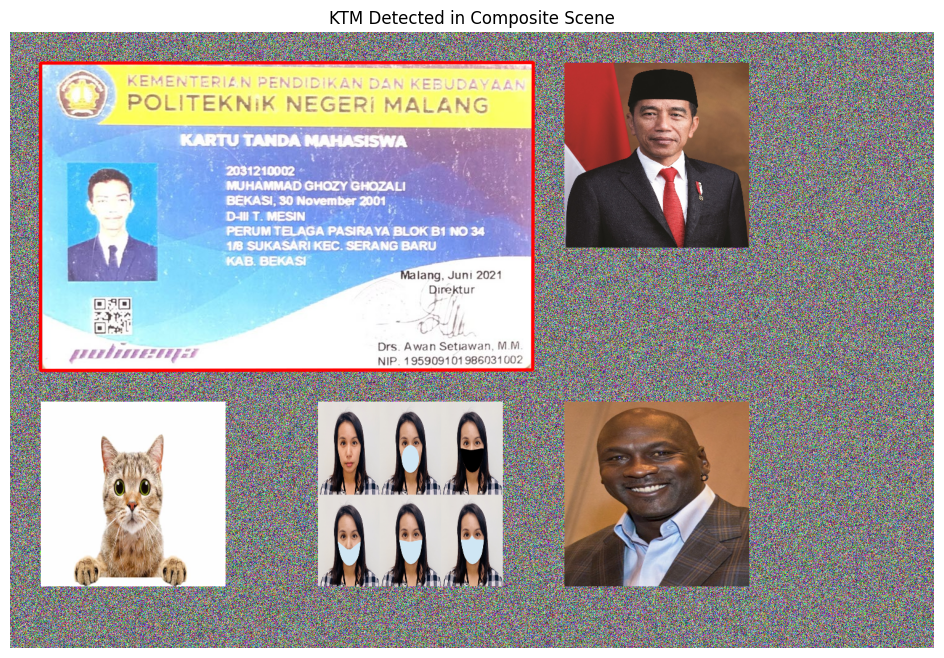

In [21]:
scene_h = 1000
scene_w = 1500

img_scene_color = np.random.randint(0, 256, (scene_h, scene_w, 3), dtype=np.uint8)

base_path_facedet = '/content/drive/MyDrive/PCVK/facedet/'
template_path = '/content/drive/MyDrive/PCVK/Image/KTM lama.jpg'

img_template_color = cv.imread(template_path)
h_ktm, w_ktm = img_template_color.shape[:2]

y_ktm, x_ktm = 50, 50
img_scene_color[y_ktm:y_ktm+h_ktm, x_ktm:x_ktm+w_ktm] = img_template_color

decoy_files = ['jokowi.jpg', 'kucing.jpg', 'mjordan.jpg', 'mask.png']
paste_locs = [(50, 900), (600, 50), (600, 900), (600, 500)]
decoy_size = (300, 300) # (w, h)

for filename, (y, x) in zip(decoy_files, paste_locs):
    img_decoy = cv.imread(base_path_facedet + filename)
    if img_decoy is not None:
        img_decoy_resized = cv.resize(img_decoy, decoy_size)
        h_d, w_d = decoy_size
        img_scene_color[y:y+h_d, x:x+w_d] = img_decoy_resized

img_scene = cv.cvtColor(img_scene_color, cv.COLOR_BGR2GRAY)
img_template = cv.cvtColor(img_template_color, cv.COLOR_BGR2GRAY)

sift = cv.SIFT_create()

kp1, des1 = sift.detectAndCompute(img_template, None)
kp2, des2 = sift.detectAndCompute(img_scene, None)

bf = cv.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

MIN_MATCH_COUNT = 10
if len(good_matches) > MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1,1,2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

    pts = np.float32([ [0,0], [0,h_ktm-1], [w_ktm-1,h_ktm-1], [w_ktm-1,0] ]).reshape(-1,1,2)

    dst = cv.perspectiveTransform(pts, M)

    img_scene_color = cv.polylines(img_scene_color, [np.int32(dst)], True, (0,0,255), 3, cv.LINE_AA)
else:
    print(f"Not enough matches found - {len(good_matches)}/{MIN_MATCH_COUNT}")

img_rgb = cv.cvtColor(img_scene_color, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title('KTM Detected in Composite Scene')
plt.axis('off')
plt.show()

# Additional practicum task

In [38]:
import kagglehub

path = kagglehub.dataset_download("dhruvildave/english-handwritten-characters-dataset")

print(f"Path to new dataset files: {path}")

Using Colab cache for faster access to the 'english-handwritten-characters-dataset' dataset.
Path to new dataset files: /kaggle/input/english-handwritten-characters-dataset


In [37]:
!ls -l /root/.cache/kagglehub/datasets/dhruvildave/english-handwritten-characters-dataset/versions/3

total 200
-rw-r--r-- 1 root root  71622 Nov 12 14:12 english.csv
drwxr-xr-x 2 root root 131072 Nov 12 14:12 Img


In [40]:
import os
import tqdm
import cv2
import random
import pickle
import pandas as pd

BASE_DATA_PATH = "/root/.cache/kagglehub/datasets/dhruvildave/english-handwritten-characters-dataset/versions/3"
CSV_PATH = os.path.join(BASE_DATA_PATH, "english.csv")
IMG_DIR = os.path.join(BASE_DATA_PATH, "Img")

data_df = pd.read_csv(CSV_PATH)
all_data = []
width, height = 100, 100

dirs = sorted(data_df['label'].unique())

for index, row in tqdm.tqdm(data_df.iterrows(), total=data_df.shape[0]):
    try:
        img_path = os.path.join(BASE_DATA_PATH, row['image'])
        class_number = dirs.index(row['label'])

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img_array is not None:
            new_array = cv2.resize(img_array, (width, height))
            all_data.append([new_array, class_number])
        else:
            pass

    except Exception as e:
        pass

random.shuffle(all_data)

split_point = int(len(all_data) * 0.8)
train_data = all_data[:split_point]
test_data = all_data[split_point:]

X_train, Y_train = [], []
for feature, label in train_data:
    X_train.append(feature)
    Y_train.append(label)

X_test, Y_test = [], []
for feature, label in test_data:
    X_test.append(feature)
    Y_test.append(label)

X_train = np.array(X_train).reshape(-1, width, height, 1)
X_test = np.array(X_test).reshape(-1, width, height, 1)

with open("X_train.pickle", "wb") as f:
    pickle.dump(X_train, f)
with open("Y_train.pickle", "wb") as f:
    pickle.dump(Y_train, f)
with open("X_test.pickle", "wb") as f:
    pickle.dump(X_test, f)
with open("Y_test.pickle", "wb") as f:
    pickle.dump(Y_test, f)
with open("dirs.pickle", "wb") as f:
    pickle.dump(dirs, f)

100%|██████████| 3410/3410 [00:49<00:00, 69.12it/s]


In [43]:
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.utils import to_categorical

with open("X_train.pickle", "rb") as f:
    X_train = pickle.load(f)
with open("Y_train.pickle", "rb") as f:
    Y_train = pickle.load(f)

num_classes = len(np.unique(Y_train))
print(f"Found {num_classes} classes for training.")

Y_train_cat = to_categorical(Y_train, num_classes=num_classes)

X_train = X_train / 255.0

width, height = 100, 100

inputs = Input(shape=(width, height, 1))

conv_layer = ZeroPadding2D(padding=(2, 2))(inputs)
conv_layer = Conv2D(16, (5, 5), strides=(1, 1), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(32, (3, 3), strides=(1, 1), activation='relu')(conv_layer)
conv_layer = Conv2D(32, (3, 3), strides=(1, 1), activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(64, (3, 3), strides=(1, 1), activation='relu')(conv_layer)

flaten = Flatten()(conv_layer)
fc_layer = Dense(256, activation='relu')(flaten)
fc_layer = Dense(64, activation='relu')(fc_layer)

outputs = Dense(num_classes, activation='softmax')(fc_layer)

adam = Adam(learning_rate=0.0001)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, Y_train_cat, epochs=20, verbose=1)

model.save('anpr.keras')

Found 62 classes for training.
Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 45s 485ms/step - accuracy: 0.0149 - loss: 4.1277
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 485ms/step - accuracy: 0.0566 - loss: 4.0116
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 487ms/step - accuracy: 0.1357 - loss: 3.4954
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 486ms/step - accuracy: 0.2556 - loss: 2.9218
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 487ms/step - accuracy: 0.3800 - loss: 2.4178
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 480ms/step - accuracy: 0.4839 - loss: 1.9734
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 468ms/step - accuracy: 0.5670 - loss: 1.6426
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 481ms/step - accuracy: 0.6662 - loss: 1.3495
Epoch 9/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 474ms/step - accuracy: 0.6910 - loss: 1.1254
Epoch 10/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 488ms/step - accuracy: 0.7539 - loss: 0.8787
Epoch 11/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 482ms/step - accuracy: 0.8116 - loss: 0.7193
Epoch 12/2

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.4633 - loss: 3.8119
Test Accuracy: 46.19%

--- Random Test Predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


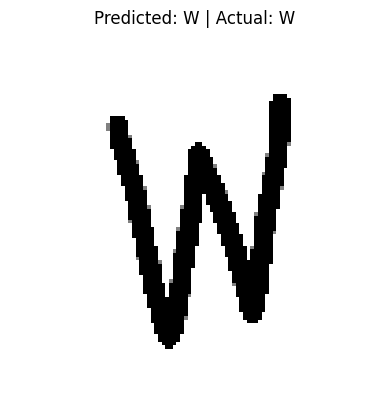

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


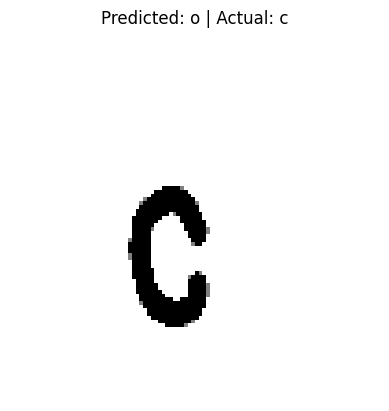

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


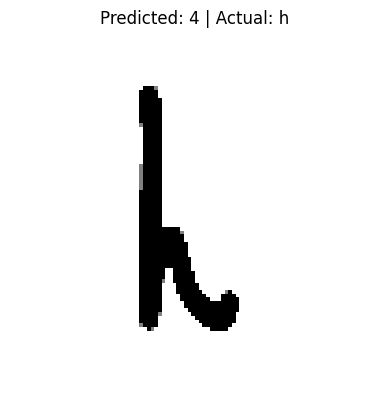

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


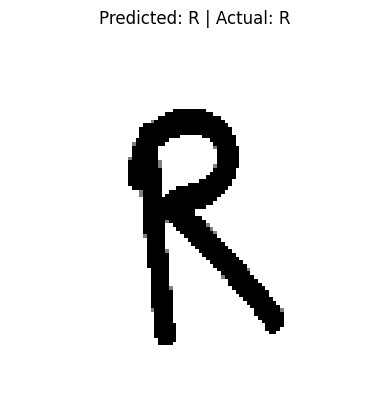

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


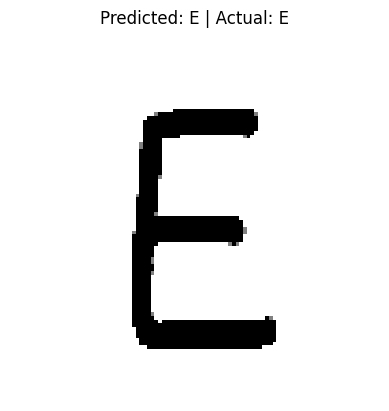

In [44]:
import tensorflow as tf

with open("X_test.pickle", "rb") as f:
    X_test = pickle.load(f)
with open("Y_test.pickle", "rb") as f:
    Y_test = pickle.load(f)
with open("dirs.pickle", "rb") as f:
    dirs = pickle.load(f)

model = tf.keras.models.load_model("anpr.keras")

X_test_norm = X_test / 255.0
num_classes = len(dirs)
Y_test_cat = to_categorical(Y_test, num_classes=num_classes)

loss, accuracy = model.evaluate(X_test_norm, Y_test_cat)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

print("\n--- Random Test Predictions ---")
for _ in range(5):
    i = random.randint(0, len(X_test) - 1)
    img = X_test[i]
    img_norm = X_test_norm[i].reshape(1, 100, 100, 1)

    prediction = model.predict(img_norm)
    predicted_class = dirs[np.argmax(prediction[0])]
    actual_class = dirs[Y_test[i]]

    plt.imshow(img.reshape(100, 100), cmap='gray')
    plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
    plt.axis('off')
    plt.show()